# Wind Power Forecasting Project
By Group 25

## Environment Setup

In [16]:
!pip install torch_geometric

In [17]:
# Standard Libraries
import random
import requests
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import math

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# PyTorch Geometric
from torch_geometric.nn.conv import GCNConv, TAGConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dense_to_sparse

# Plotting
import matplotlib.pyplot as plt

To ensure reproducible results:

In [18]:
SEED = 101

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## LSTM Baseline
### Parameter Configuration
Below are the hyperparameters used for the LSTM baseline predictions.

In [19]:
SEQ_LEN = 24 # (1 step = 10 min -> 24 steps = 4 hours)
BATCH_SIZE = 32
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 1e-3
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Data Analysis & Preparation

In [20]:
df_wind = pd.read_csv("/kaggle/input/wind-farm-power-forecasting/85b5cb4eea5a4f259766f42a448e2c04a7499c43e1ae4cc28fbdee8e087e2385")
df_wind.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,TurbID,Day,Tmstamp,Wspd,Wdir,Etmp,Itmp,Ndir,Pab1,Pab2,Pab3,Prtv,Patv
0,1,1,00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,00:10,6.17,-3.99,30.73,41.80,25.92,1.0,1.0,1.0,-0.25,494.66
2,1,1,00:20,6.27,-2.18,30.60,41.63,20.91,1.0,1.0,1.0,-0.24,509.76
3,1,1,00:30,6.42,-0.73,30.52,41.52,20.91,1.0,1.0,1.0,-0.26,542.53
4,1,1,00:40,6.25,0.89,30.49,41.38,20.91,1.0,1.0,1.0,-0.23,509.36


In [21]:
df_wind.describe()

,TurbID,Day,Wspd,Wdir,Etmp,Itmp,Ndir,Pab1,Pab2,Pab3,Prtv,Patv
count,4.727520e+06,4.727520e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06
mean,6.750000e+01,1.230000e+02,5.028376e+00,4.975428e-01,4.110668e+01,2.739717e+01,1.885826e+02,2.685400e+01,2.683916e+01,2.682679e+01,-1.323900e+01,3.504458e+02
std,3.868139e+01,7.072483e+01,3.393703e+00,3.160275e+01,8.529011e+01,1.832832e+01,1.632459e+02,3.883566e+01,3.882940e+01,3.882235e+01,7.044244e+01,4.249932e+02
min,1.000000e+00,1.000000e+00,0.000000e+00,-3.030460e+03,-2.730300e+02,-2.731700e+02,-8.848600e+02,-1.000000e+01,-1.000000e+01,-1.000000e+01,-6.249800e+02,-9.330000e+00
25%,3.400000e+01,6.200000e+01,2.240000e+00,-3.830000e+00,1.405000e+01,2.006000e+01,6.302000e+01,1.000000e-02,1.000000e-02,1.000000e-02,-3.861000e+01,-3.000000e-01
50%,6.750000e+01,1.230000e+02,4.340000e+00,-2.300000e-01,2.573000e+01,3.008000e+01,1.947900e+02,5.400000e-01,5.400000e-01,5.400000e-01,-3.000000e-01,1.790800e+02
75%,1.010000e+02,1.840000e+02,7.010000e+00,3.420000e+00,3.273000e+01,3.682000e+01,3.219600e+02,8.399000e+01,8.398000e+01,8.398000e+01,-3.000000e-02,5.476600e+02
max,1.340000e+02,2.450000e+02,2.629000e+01,2.266950e+03,3.943300e+02,3.242100e+02,7.006200e+02,9.998000e+01,9.998000e+01,9.998000e+01,4.852000e+02,1.567020e+03


In [22]:
column_nan_count = df_wind.isnull().sum()
print("NaN count per column:")
print(column_nan_count)

NaN count per column:
TurbID         0
Day            0
Tmstamp        0
Wspd       49518
Wdir       49518
Etmp       49518
Itmp       49518
Ndir       49518
Pab1       49518
Pab2       49518
Pab3       49518
Prtv       49518
Patv       49518
dtype: int64


We see that the amount of NaNs is the same for each feature. So, at certain timestamps, there were no readings at all. There are no cases where we only had partial information about the sensor values.

In [23]:
# Keep only one turbine for now
df_wind_1 = df_wind[df_wind["TurbID"] == 1].copy()
df_wind_1.shape

(35280, 13)

In [24]:
# Fill missing values (simple method, more sophisticated imputation later)
df_wind_1 = df_wind_1.ffill().bfill()
df_wind_1.head()

,TurbID,Day,Tmstamp,Wspd,Wdir,Etmp,Itmp,Ndir,Pab1,Pab2,Pab3,Prtv,Patv
0,1,1,00:00,6.17,-3.99,30.73,41.80,25.92,1.0,1.0,1.0,-0.25,494.66
1,1,1,00:10,6.17,-3.99,30.73,41.80,25.92,1.0,1.0,1.0,-0.25,494.66
2,1,1,00:20,6.27,-2.18,30.60,41.63,20.91,1.0,1.0,1.0,-0.24,509.76
3,1,1,00:30,6.42,-0.73,30.52,41.52,20.91,1.0,1.0,1.0,-0.26,542.53
4,1,1,00:40,6.25,0.89,30.49,41.38,20.91,1.0,1.0,1.0,-0.23,509.36


In [25]:
FEATURES = ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", "Pab1", "Pab2", "Pab3", "Prtv"]
TARGET = "Patv"

X = df_wind_1[FEATURES].values
y = df_wind_1[TARGET].values.reshape(-1, 1)

# Standardize features (only do on training later)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

Now that the data has been preprocessed, we can construct a Data Loader on which we will train our model.

In [26]:
class WindDataset(Dataset):
    def __init__(self, X, y, seq_len=12):
        self.X, self.y = [], []
        for i in range(len(X) - seq_len):
            self.X.append(X[i:i + seq_len])
            self.y.append(y[i + seq_len]) # Predict the next time step
        self.X, self.y = np.array(self.X), np.array(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )

In [27]:
dataset = WindDataset(X, y, seq_len=SEQ_LEN)
train_size = int(0.8 * len(dataset))
train_data, test_data = torch.utils.data.random_split(dataset, [train_size, len(dataset) - train_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

### LSTM Model
The LSTM model consists of an LSTM unit connected to a fully connected layer.

In [28]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) # Use the last time step's
        return out

In [29]:
model = LSTMForecaster(input_size=len(FEATURES), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
model.to(DEVICE)

LSTMForecaster(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

### Model training

In [30]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}")

RuntimeError: Input and parameter tensors are not at the same device, found input tensor at cpu and parameter tensor at cuda:0

In [ ]:
# Plotting the Training Loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

### Model Evaluation

In [ ]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        preds.extend(y_pred.numpy())
        trues.extend(y_batch.numpy())

preds = np.array(preds)
trues = np.array(trues)

mse = np.mean((preds - trues) ** 2)
print("Test MSE:", mse)

In [ ]:
# Plotting the Prediction vs Actual
step = 250  # plot every 10th sample
plt.figure(figsize=(12, 6))
plt.plot(trues[::step], label="True Patv", alpha=0.7)
plt.plot(preds[::step], label="Predicted Patv", alpha=0.7)
plt.title("LSTM Forecast: True vs Predicted Patv (Downsampled)")
plt.xlabel("Sample")
plt.ylabel("Patv")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Multi-Step Evaluation
Hyperparameter Configuration

In [ ]:
HORIZON = 12        # steps ahead to predict
MAX_SAMPLES = 20    # limit number of sequences to evaluate for speed

Evaluation Loop

In [ ]:
n_eval = min(len(test_indices), MAX_SAMPLES)
with torch.no_grad():
    for k in range(n_eval):
        start = test_indices[k]                # start index in original X/y (sequence begins here)
        seq = test_data[start]
        preds_scaled = []
        trues_scaled = []

        # generate up to HORIZON steps, but stop if true future features/targets unavailable
        for t in range(HORIZON):
            inp = seq[0].unsqueeze(0).to(DEVICE)   # (1, SEQ_LEN, N, F)
            out = model(inp, edge_index, edge_weight)                                         # (1,N)
            pred_val = out.cpu().numpy().ravel()[0]
            preds_scaled.append(pred_val)

            # append true future target (scaled)
            trues_scaled.append(seq[1].ravel()[0])
            
            true_idx = start + t + 1
            if true_idx >= len(test_data):
                # no more true future data -> stop expanding horizon for this sequence
                break

            # shift window for next autoregressive step
            seq = test_data[start + t + 1]

        preds_scaled = np.array(preds_scaled)
        trues_scaled = np.array(trues_scaled)  # length may be <= HORIZON

        all_preds.append(preds_scaled)
        all_trues.append(trues_scaled)

        # accumulate squared error per horizon index where true exists
        for h in range(len(trues_scaled)):
            err2 = (preds_scaled[h] - trues_scaled[h]) ** 2
            mse_sum[h] += err2
            counts[h] += 1

Log Results

In [ ]:
# finalize MSE per horizon
mse_per_horizon = np.full(HORIZON, np.nan)
valid = counts > 0
mse_per_horizon[valid] = mse_sum[valid] / counts[valid]

# print results
for h in range(HORIZON):
    if counts[h] > 0:
        print(f"Horizon {h+1}: MSE (scaled) = {mse_per_horizon[h]:.6f} over {counts[h]} samples")
    else:
        print(f"Horizon {h+1}: no valid samples")

Plotting Multi-Step Predictions

In [ ]:
plt.figure(figsize=(8,4))
hs = np.arange(1, HORIZON+1)
plt.plot(hs, mse_per_horizon, marker='o', label='MSE (scaled)')
plt.xlabel("Horizon (steps ahead)")
plt.ylabel("MSE")
plt.title("Autoregressive multi-step MSE (using true future features)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## LSTM + GCN Hybrid

In [31]:
# TODO Standardize features
df_positions = pd.read_csv(
    "/kaggle/input/wind-farm-power-forecasting/e927ce742c884955bf2a667929d36b2ef41c572cd6e245fa86257ecc2f7be7bc")
df_predictions = pd.read_csv(
    "/kaggle/input/wind-farm-power-forecasting/85b5cb4eea5a4f259766f42a448e2c04a7499c43e1ae4cc28fbdee8e087e2385")

def build_spatial_graph(positions, sigma_s=1000):
    dist = cdist(positions, positions)
    W = np.exp(-dist ** 2 / (2 * sigma_s ** 2))
    np.fill_diagonal(W, 0)
    return W

positions = df_positions[["x", "y"]].values
W = build_spatial_graph(positions)
D = np.diag(W.sum(axis=1))
L = D - W

def harmonic_interpolation_one_timestep(values, L, W):
    observed_mask = ~np.isnan(values)
    unlabeled_mask = np.isnan(values)
    if unlabeled_mask.sum() == 0:
        return values
    labeled_idx = np.where(observed_mask)[0]
    unlabeled_idx = np.where(unlabeled_mask)[0]
    L_uu = L[np.ix_(unlabeled_idx, unlabeled_idx)]
    L_ul = L[np.ix_(unlabeled_idx, labeled_idx)]
    f_L = values[labeled_idx]
    f_U = -np.linalg.solve(L_uu, L_ul @ f_L)
    filled = np.copy(values)
    filled[unlabeled_idx] = f_U
    return filled

data = df_predictions.sort_values(["Day", "Tmstamp", "TurbID"])
turbine_ids = sorted(data["TurbID"].unique())
features = ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", "Pab1", "Pab2", "Pab3", "Prtv", "Patv"]
filled_records = []
for (day, tstamp), group in data.groupby(["Day", "Tmstamp"]):
    group = group.set_index("TurbID").reindex(turbine_ids)
    filled_group = group.copy()
    for feat in features:
        vals = group[feat].to_numpy(dtype=float)
        filled_vals = harmonic_interpolation_one_timestep(vals, L, W)
        filled_group[feat] = filled_vals
    filled_records.append(filled_group.reset_index())
df_predictions_imputed = pd.concat(filled_records, ignore_index=True)
df_predictions_imputed['datetime'] = pd.to_datetime(
    df_predictions_imputed['Day'].astype(str) + ' ' + df_predictions_imputed['Tmstamp'],
    format='%j %H:%M')
scaler_X = StandardScaler()
df_predictions_imputed[features] = scaler_X.fit_transform(df_predictions_imputed[features])

In [32]:
unique_times = df_predictions_imputed['datetime'].sort_values().unique()

train_end = int(len(unique_times) * 0.7)
test_end = int(len(unique_times) * 0.85)

train_times = unique_times[:train_end]
test_times = unique_times[train_end:test_end]
val_times = unique_times[test_end:]

train_df = df_predictions_imputed[df_predictions_imputed['datetime'].isin(train_times)]
val_df = df_predictions_imputed[df_predictions_imputed['datetime'].isin(val_times)]
test_df = df_predictions_imputed[df_predictions_imputed['datetime'].isin(test_times)]
feature_cols = ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Ndir', 'Pab1', 'Pab2', 'Pab3', 'Prtv', 'Patv']
target_col = 'Patv'


class WindDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = X
        self.y = y
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        return (
            self.X[idx:idx + self.seq_len],
            self.y[idx + self.seq_len]
        )

def create_dataset(dataset_df):
    timesteps = []
    targets = []
    for t, group in dataset_df.groupby('datetime'):
        group = group.sort_values('TurbID')
        x = torch.tensor(group[feature_cols].values, dtype=torch.float)
        y = torch.tensor(group[target_col].values, dtype=torch.float)
        timesteps.append(x)
        targets.append(y)
    timesteps_tensor = torch.stack(timesteps)
    y_full = torch.stack(targets)
    return WindDataset(timesteps_tensor, y_full, seq_len=SEQ_LEN)

train_data = create_dataset(train_df)
test_data = create_dataset(test_df)
val_data = create_dataset(val_df)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False, drop_last=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False, drop_last=True)
W_tensor = torch.tensor(W, dtype=torch.float, device=DEVICE)

Now that the data has been preprocessed, we can construct a Data Loader on which we will train our model.

In [33]:
# Batched Dynamic Edge Attention (supports x: [B, N, F])
class BatchedDynamicEdgeAttention(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.Wq = nn.Linear(in_dim, hidden_dim)
        self.Wk = nn.Linear(in_dim, hidden_dim)
        self.scale = math.sqrt(hidden_dim)
        self.beta = nn.Parameter(torch.tensor(1.0))

    def forward(self, x, W):
        # x: [B, N, F]
        # W: [N, N] or [B, N, N] (static affinity)
        B, N, F = x.shape
        Q = self.Wq(x)      # [B, N, H]
        K = self.Wk(x)      # [B, N, H]
        # raw attention: batch bmm
        raw_attn = torch.matmul(Q, K.transpose(-1, -2)) / self.scale  # [B, N, N]
        A = torch.softmax(raw_attn, dim=-1)                           # [B, N, N]
        # Ensure W is batched
        if len(W.shape) == 2:
            Wb = W.unsqueeze(0).expand(B, -1, -1)  # [B, N, N]
        else:
            Wb = W
        A_dyn = A * (1.0 + self.beta * Wb)
        A_dyn = A_dyn / (A_dyn.sum(dim=-1, keepdim=True) + 1e-8)      # row-normalize
        return A_dyn  # [B, N, N]

# helper: convert batched dense adj [B,N,N] -> global edge_index [2, E] and edge_weight [E]
def batched_dense_adj_to_edge_index_and_weight(A_dyn):
    # A_dyn: [B, N, N]
    B, N, _ = A_dyn.shape
    E_per_graph = N * N
    # base indices for a single graph (row -> source, col -> target)
    rows = torch.arange(N, device=DEVICE).unsqueeze(1).repeat(1, N).reshape(-1)  # (N*N,)
    cols = torch.arange(N, device=DEVICE).repeat(N)                              # (N*N,)
    # repeat for B graphs and offset indices per graph
    rows_rep = rows.repeat(B)  # (B*N*N,)
    cols_rep = cols.repeat(B)
    offsets = (torch.arange(B, device=DEVICE) * N).repeat_interleave(E_per_graph)  # (B*N*N,)
    edge_index = torch.stack([rows_rep + offsets, cols_rep + offsets], dim=0)  # [2, B*N*N]
    edge_weight = A_dyn.reshape(-1)  # [B*N*N]
    return edge_index, edge_weight

class AttentiveDenseGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, use_relu=True):
        super().__init__()
        self.attn = BatchedDynamicEdgeAttention(in_dim, hidden_dim)
        self.conv = TAGConv(in_dim, out_dim, K=2)
        self.use_relu = use_relu

    def forward(self, x, W):
        # x: [B*T, N, F]
        # W: [N,N] or [B,N,N]
        BT, N, F = x.shape
        A = self.attn(x, W)                    # [B*T, N, N]
        edge_index, edge_weight = batched_dense_adj_to_edge_index_and_weight(A)
        x_flat = x.reshape(BT * N, F)
        h = self.conv(x_flat, edge_index, edge_weight)  # [BT*N, out_dim]
        if self.use_relu:
            h = torch.relu(h)
        return h                               # [B, N, out_dim]

# 1) Spatial-first: per-timestep GCN -> LSTM across time for each node
class SpatialFirst_GCN_then_LSTM(nn.Module):
    def __init__(self, node_in_dim=10, attn_hidden=64, gcn_out=64,
                 lstm_hidden=128, lstm_layers=1, #lstm_bidirectional=False,
                 final_out_dim=1):
        super().__init__()
        self.gcn = AttentiveDenseGCN(node_in_dim, attn_hidden, gcn_out)
        self.lstm_hidden = lstm_hidden
        self.lstm = nn.LSTM(input_size=gcn_out,
                            hidden_size=lstm_hidden,
                            num_layers=lstm_layers,
                            batch_first=True)
                            # bidirectional=lstm_bidirectional)
        # dir_mul = 2 if lstm_bidirectional else 1
        # self.final = nn.Linear(lstm_hidden * dir_mul, final_out_dim)
        self.final = nn.Linear(lstm_hidden, final_out_dim)

    def forward(self, x, W):
        # x: [B, T, N, F]
        B, T, N, F = x.shape
        # Apply GCN per timestep (vectorized loop over T)
        gcn_outs = x.reshape(B * T, N, F)
        gcn_outs = self.gcn(gcn_outs, W)        # [B * T, N, gcn_out]
        gcn_seq = gcn_outs.reshape(B, T, N, -1)   # [B, T, N, gcn_out]
        # Prepare for LSTM: we want an LSTM per node across time.
        # reshape to (B*N, T, gcn_out)
        gcn_seq = gcn_seq.permute(0, 2, 1, 3).contiguous()  # [B, N, T, gcn_out]
        gcn_seq = gcn_seq.view(B * N, T, -1)                # [B*N, T, gcn_out]
        # LSTM across time for each (batch,node)
        lstm_out, (h_n, c_n) = self.lstm(gcn_seq)           # lstm_out: [B*N, T, H]
        # choose last timestep output (or h_n)
        last = lstm_out[:, -1, :]                          # [B*N, lstm_hidden * dir]
        last = last.view(B, N, -1)                         # [B, N, lstm_hidden*dir]
        out = self.final(last).squeeze(-1)                             # [B, N, final_out_dim]
        return out

In [34]:
model = SpatialFirst_GCN_then_LSTM(node_in_dim=len(features))
model.to(DEVICE)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []

best_val_loss = float('inf')
epochs_no_improve = 0
early_stop_patience = 5  # stop after 2 bad epochs
best_model_path = "/kaggle/working/best_lstm_gnn_attention.pth"

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    for i, (X_batch, y_batch) in enumerate(train_loader):
        optimizer.zero_grad()
        y_pred = model(X_batch.to(DEVICE), W_tensor)
        loss = criterion(y_pred, y_batch.to(DEVICE))
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        if i % 100 == 0:
            print(f"{i}/{len(train_loader)} batches")

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATE ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch.to(DEVICE), W_tensor)
            loss = criterion(y_pred, y_batch.to(DEVICE))
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")

    # --- SAVE MODEL EACH EPOCH ---
    torch.save(model.state_dict(), f"/kaggle/working/lstm_gnn_attention_epoch{epoch+1}.pth")

    # --- CHECK FOR BEST MODEL ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        print("New best model saved")
    else:
        epochs_no_improve += 1
        print(f"Validation loss worsened")

    # --- EARLY STOPPING ---
    if epochs_no_improve >= early_stop_patience:
        print("Early stopping triggered.")
        break

print("Training complete.")
print(f"Best model saved at: {best_model_path}")

0/1542 batches
100/1542 batches
200/1542 batches
300/1542 batches
400/1542 batches
500/1542 batches
600/1542 batches
700/1542 batches
800/1542 batches
900/1542 batches
1000/1542 batches
1100/1542 batches
1200/1542 batches
1300/1542 batches
1400/1542 batches
1500/1542 batches
Epoch 1/20
  Train Loss: 0.1698
  Val Loss:   0.1200
New best model saved
0/1542 batches
100/1542 batches
200/1542 batches
300/1542 batches
400/1542 batches
500/1542 batches
600/1542 batches
700/1542 batches
800/1542 batches
900/1542 batches
1000/1542 batches
1100/1542 batches
1200/1542 batches
1300/1542 batches
1400/1542 batches
1500/1542 batches
Epoch 2/20
  Train Loss: 0.1542
  Val Loss:   0.1203
Validation loss worsened
0/1542 batches
100/1542 batches
200/1542 batches
300/1542 batches
400/1542 batches
500/1542 batches
600/1542 batches
700/1542 batches
800/1542 batches
900/1542 batches
1000/1542 batches
1100/1542 batches
1200/1542 batches
1300/1542 batches
1400/1542 batches
1500/1542 batches
Epoch 3/20
  Train L

In [35]:
model.load_state_dict(torch.load("/kaggle/working/best_lstm_gnn_attention.pth", map_location=torch.device(DEVICE)))
model.to(DEVICE)
model.eval()
preds, trues = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch.to(DEVICE), W_tensor)
        preds.extend(y_pred.cpu().numpy())
        trues.extend(y_batch.numpy())

preds = np.array(preds)
trues = np.array(trues)

mae = np.mean(abs(preds - trues))
print("Test MAE:", mae)

Test MAE: 0.11042637


In [36]:
edge_index, edge_weight = dense_to_sparse(W_tensor)

def batched_edge_index(edge_index, N, B, device):
    rows = edge_index[0].unsqueeze(0) + (torch.arange(B, device=device)*N).view(B,1)
    cols = edge_index[1].unsqueeze(0) + (torch.arange(B, device=device)*N).view(B,1)
    return torch.cat([rows, cols], dim=0).reshape(2, -1)

B = train_loader.batch_size
edge_index_batched = batched_edge_index(edge_index, 134, B * SEQ_LEN, DEVICE)
edge_weight_batched = edge_weight.unsqueeze(0).repeat(B * SEQ_LEN, 1).view(-1).to(DEVICE)

In [37]:
class LSTMGCNForecaster(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers):
        super().__init__()
        self.gnn = nn.ModuleList()
        self.gnn.append(TAGConv(input_size, 50, K=2))
        # self.gnn.append(TAGConv(50, 50, K=2))
        self.gnn.append(TAGConv(50, 50, K=2))
        # for i in range(2):
            # self.gnn.append(GCNConv(in_channels=input_size, out_channels=input_size))
        self.lstm = nn.LSTM(50, hidden_dim, num_layers, batch_first=True)
        # self.gnn = GCN(in_channels=input_size, hidden_channels=input_size, num_layers=2)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index_batched, edge_weight_batched):
        B, T, N, F = x.shape
        xt = x.reshape(B * T * N, F)
        for i, conv in enumerate(self.gnn):
            xt = conv(x=xt, edge_index=edge_index_batched, edge_weight=edge_weight_batched)
            xt = torch.relu(xt)
        y = xt.reshape(B, T, N, 50)
        y = y.permute(0, 2, 1, 3).reshape(B * N, T, 50)
        out, _ = self.lstm(y)
        out = self.fc(out[:, -1, :]) # Use the last time step's
        out = out.squeeze(-1).reshape(B, N)
        return out

In [38]:
model = LSTMGCNForecaster(input_size=len(features), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
model.to(DEVICE)
for x, y in train_loader:
    print(x.shape)
    print(y.shape)
    print(model(x.to(DEVICE), edge_index_batched, edge_weight_batched).shape)
    break

torch.Size([16, 24, 134, 10])
torch.Size([16, 134])
torch.Size([16, 134])


In [39]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for i, (X_batch, y_batch) in enumerate(train_loader):
        optimizer.zero_grad()
        y_pred = model(X_batch.to(DEVICE), edge_index_batched, edge_weight_batched)
        loss = criterion(y_pred, y_batch.to(DEVICE))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if i % 100 == 0:
            print(f"{i} / {len(train_loader)}")
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}")
torch.save(model.state_dict(), "/kaggle/working/lstm_gnn.pth")

0 / 1542
100 / 1542
200 / 1542
300 / 1542
400 / 1542
500 / 1542
600 / 1542
700 / 1542
800 / 1542
900 / 1542
1000 / 1542
1100 / 1542
1200 / 1542
1300 / 1542
1400 / 1542
1500 / 1542
Epoch 1, Train Loss: 0.1017
0 / 1542
100 / 1542
200 / 1542
300 / 1542
400 / 1542
500 / 1542
600 / 1542
700 / 1542
800 / 1542
900 / 1542
1000 / 1542
1100 / 1542
1200 / 1542
1300 / 1542
1400 / 1542
1500 / 1542
Epoch 2, Train Loss: 0.0791
0 / 1542
100 / 1542
200 / 1542
300 / 1542
400 / 1542
500 / 1542
600 / 1542
700 / 1542
800 / 1542
900 / 1542
1000 / 1542
1100 / 1542
1200 / 1542
1300 / 1542
1400 / 1542
1500 / 1542
Epoch 3, Train Loss: 0.0770
0 / 1542
100 / 1542
200 / 1542
300 / 1542
400 / 1542
500 / 1542
600 / 1542
700 / 1542
800 / 1542
900 / 1542
1000 / 1542
1100 / 1542
1200 / 1542
1300 / 1542
1400 / 1542
1500 / 1542
Epoch 4, Train Loss: 0.0746
0 / 1542
100 / 1542
200 / 1542
300 / 1542
400 / 1542
500 / 1542
600 / 1542
700 / 1542
800 / 1542
900 / 1542
1000 / 1542
1100 / 1542
1200 / 1542
1300 / 1542
1400 / 1542


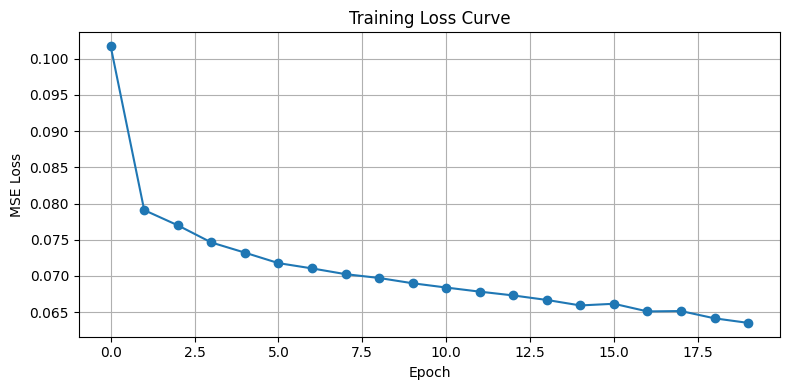

In [40]:
# Plotting the Training Loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# model.load_state_dict(torch.load("/kaggle/input/lstm-gnn/pytorch/default/1/lstm_gnn.pth", map_location=torch.device(DEVICE)))
# model.to(DEVICE)
# model.eval()

In [43]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch.to(DEVICE), edge_index_batched, edge_weight_batched)
        preds.extend(y_pred.cpu().numpy())
        trues.extend(y_batch.numpy())

preds = np.array(preds)
trues = np.array(trues)

mse = np.mean((preds - trues) ** 2)
print("Test MSE:", mse)

Test MSE: 0.042553063


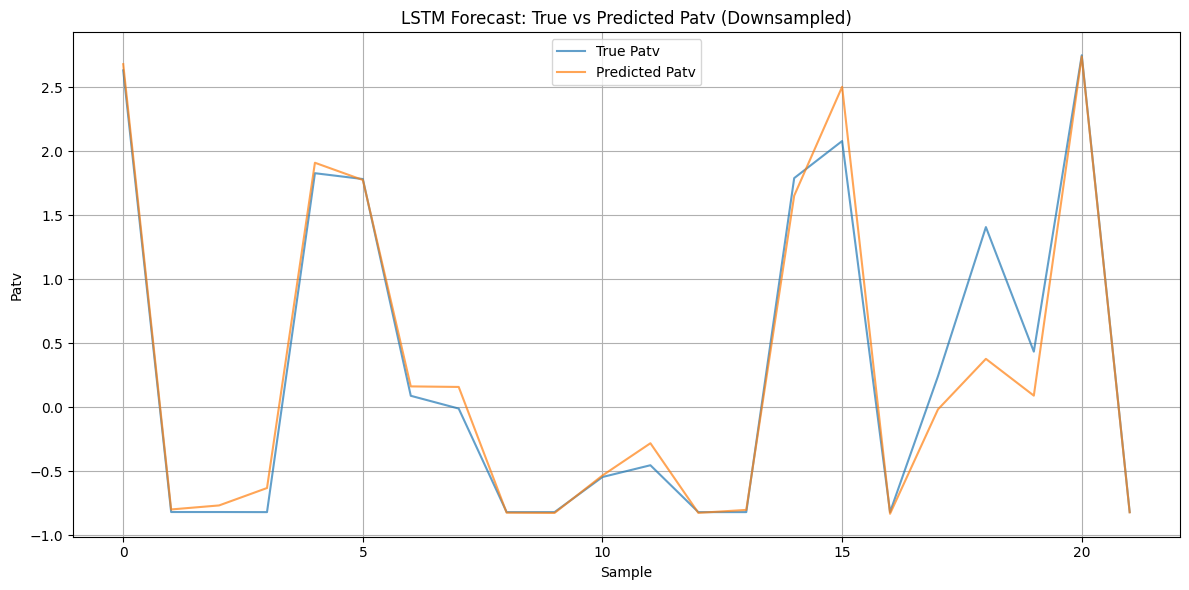

In [42]:
# Plotting the Prediction vs Actual
step = 250  # plot every 10th sample
plt.figure(figsize=(12, 6))
plt.plot(trues[::step, 0], label="True Patv", alpha=0.7)
plt.plot(preds[::step, 0], label="Predicted Patv", alpha=0.7)
plt.title("LSTM Forecast: True vs Predicted Patv (Downsampled)")
plt.xlabel("Sample")
plt.ylabel("Patv")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Evaluation Loop

Log results

Plotting Multi-Step Prediction Results

Adding the regularizer

In [79]:
def unit_dist_turbines(df_positions):
    coords = df_positions.set_index("TurbID")[["x", "y"]].to_dict("index")
    turb_ids = list(coords.keys())
    pairs = {}

    for i, ti in enumerate(turb_ids):
        for j, tj in enumerate(turb_ids):
            if ti == tj: 
                continue
            dx = coords[tj]["x"] - coords[ti]["x"]
            dy = coords[tj]["y"] - coords[ti]["y"]
            dist = np.sqrt(dx**2 + dy**2)
            if dist == 0:
                continue
            pairs[(ti, tj)] = (np.array([dx, dy]) / dist, dist)
    return pairs
    
distances = unit_dist_turbines(df_positions)

In [ ]:
def wake_regularizer(pred_patv, wind_dir, nacelle_dir, wind_speed, distances, cone_half_angle=45):
    """
    pred_patv : (B, N) predicted power for each turbine
    wind_dir  : (B, N) wind direction (degrees from nacelle)
    nacelle_dir  : (B, N) nacelle direction - yaw angle (degrees from north)
    wind_speed : (B, N) wind speed recorded in each turbine
    distances : tuple dictionary
    """
    B, N = pred_patv.shape
    device = pred_patv.device
    loss_wake = torch.zeros((), device=device)

    cos_limit = np.cos(np.deg2rad(cone_half_angle))

    for b in range(B):
        for i in range(1, N + 1):
            wind_from = (nacelle_dir[b, i-1] + wind_dir[b, i-1]) % 360
            downwind_dir = (wind_from + 180) % 360
            downwind_dir_rad = torch.tensor([downwind_dir], dtype=torch.float32, device=device)[0]
            downwind_dir_rad = torch.deg2rad(downwind_dir_rad)
            wx, wy = torch.cos(downwind_dir_rad), torch.sin(downwind_dir_rad)
            wvec = torch.stack([wx, wy])
        
            for j in range(1, N + 1):
                if i == j:
                    continue
                v_ij_unit = torch.tensor(distances[(i, j)][0], dtype=torch.float32, device=device)
                cos_angle = torch.dot(v_ij_unit, wvec)
        
                if cos_angle > cos_limit:
                    violation = torch.relu(pred_patv[b, j-1] - pred_patv[b, i-1])
                    weight = (1.0 / (distances[(i, j)][1]**2)) * cos_angle * wind_speed[b, i-1] ** 3
                    loss_wake += violation * weight
            
    return loss_wake / B

model_phys = LSTMGCNForecaster(input_size=len(features), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
model_phys.to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
lambda_wake = 0.01  # to fine-tune


train_losses = []

for epoch in range(EPOCHS):
    model_phys.train()
    total_loss = 0
    for i, (X_batch, y_batch) in enumerate(train_loader):
        optimizer.zero_grad()
        y_pred = model_phys(X_batch.to(DEVICE), edge_index_batched, edge_weight_batched)
        loss_pred = criterion(y_pred, y_batch.to(DEVICE))
        
        # ------------- regularizer loss -------------
        idx_wdir = feature_cols.index('Wdir')
        idx_nac  = feature_cols.index('Ndir')
        idx_wspd = feature_cols.index('Wspd')

        B, T, N, F = X_batch.shape #torch.Size([16, 24, 134, 10])

        # take last timestep from the sequence, inverse transform to original units
        last_feats = X_batch[:, -1, :, :].cpu().numpy().reshape(B * N, F)
        last_feats_unscaled = scaler_X.inverse_transform(last_feats).reshape(B, N, F)

        wind_dir_batch = torch.tensor(last_feats_unscaled[:, :, idx_wdir], dtype=torch.float32)   # (B, N)
        nacelle_dir_batch = torch.tensor(last_feats_unscaled[:, :, idx_nac], dtype=torch.float32)  # (B, N)
        wind_speed_batch = torch.tensor(last_feats_unscaled[:, :, idx_wspd], dtype=torch.float32)  # (B, N)
        
        loss_reg = wake_regularizer(y_pred, wind_dir_batch, nacelle_dir_batch, wind_speed_batch, distances)
        # ------------- regularizer loss -------------
        print("loss reg: ", loss_reg)
        
        loss = loss_pred + lambda_wake * loss_reg
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if i % 100 == 0:
            print(f"{i} / {len(train_loader)}")
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}")
torch.save(model_phys.state_dict(), "/kaggle/working/lstm_gnn_phys.pth")

loss reg:  tensor(0.0003, device='cuda:0', grad_fn=<DivBackward0>)
0 / 1542
loss reg:  tensor(0.0004, device='cuda:0', grad_fn=<DivBackward0>)
loss reg:  tensor(0.0003, device='cuda:0', grad_fn=<DivBackward0>)
loss reg:  tensor(0.0001, device='cuda:0', grad_fn=<DivBackward0>)
loss reg:  tensor(0.0004, device='cuda:0', grad_fn=<DivBackward0>)
loss reg:  tensor(0.0003, device='cuda:0', grad_fn=<DivBackward0>)
loss reg:  tensor(0.0002, device='cuda:0', grad_fn=<DivBackward0>)
loss reg:  tensor(0.0007, device='cuda:0', grad_fn=<DivBackward0>)
loss reg:  tensor(0.0004, device='cuda:0', grad_fn=<DivBackward0>)
loss reg:  tensor(0.0003, device='cuda:0', grad_fn=<DivBackward0>)


------------------------------------------------------------------------------
Beyond baseline below

In [ ]:
df_positions = pd.read_csv("/kaggle/input/wind-farm-power-forecasting/e927ce742c884955bf2a667929d36b2ef41c572cd6e245fa86257ecc2f7be7bc")
df_predictions = pd.read_csv("/kaggle/input/wind-farm-power-forecasting/85b5cb4eea5a4f259766f42a448e2c04a7499c43e1ae4cc28fbdee8e087e2385")

In [ ]:
print("Predictions:", df_predictions)
print("Positions:", df_positions)

#### Dataset features

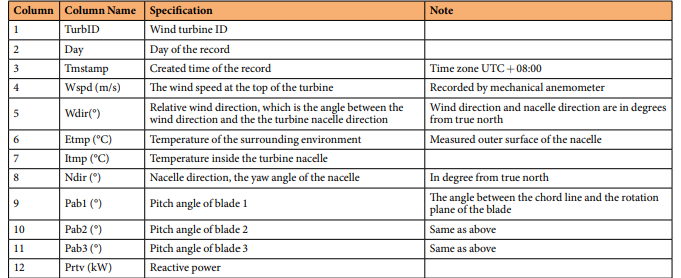
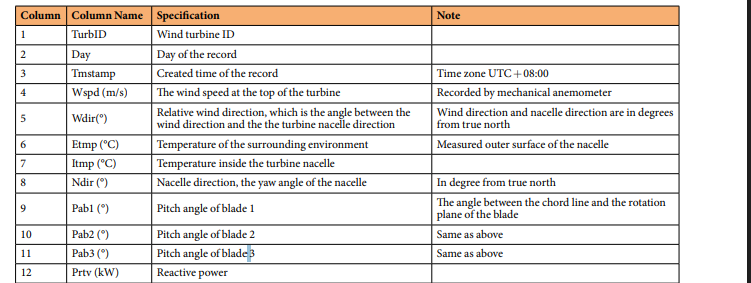

#### Distance graph matrices (dist is transformed into Gaussian similarity)

In [ ]:
def build_spatial_graph(positions, sigma_s=1000):
    dist = cdist(positions, positions)
    W = np.exp(-dist ** 2 / (2 * sigma_s ** 2))
    np.fill_diagonal(W, 0)
    return W

positions = df_positions[["x", "y"]].values

## Weighted adjacency matrix of the graph
W = build_spatial_graph(positions)
W

In [ ]:
## Degree and Laplacian matrix
D = np.diag(W.sum(axis=1))
L = D - W

### Missing value interpolation

In [ ]:
## One timestamp harmonic interpolation

def harmonic_interpolation_one_timestep(values, L, W):
    observed_mask = ~np.isnan(values)
    unlabeled_mask = np.isnan(values)

    if unlabeled_mask.sum() == 0:
        return values  # no missing values

    labeled_idx = np.where(observed_mask)[0]
    unlabeled_idx = np.where(unlabeled_mask)[0]

    L_uu = L[np.ix_(unlabeled_idx, unlabeled_idx)]
    L_ul = L[np.ix_(unlabeled_idx, labeled_idx)]

    f_L = values[labeled_idx]
    f_U = -np.linalg.solve(L_uu, L_ul @ f_L)

    filled = np.copy(values)
    filled[unlabeled_idx] = f_U
    return filled

In [ ]:
data = df_predictions.sort_values(["Day", "Tmstamp", "TurbID"])
turbine_ids = sorted(data["TurbID"].unique())
features = ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", "Pab1", "Pab2", "Pab3", "Prtv", "Patv"]
filled_records = []

# Group by each timestamp (Day + Tmstamp)
for (day, tstamp), group in data.groupby(["Day", "Tmstamp"]):
    group = group.set_index("TurbID").reindex(turbine_ids)
    filled_group = group.copy()

    for feat in features:
        vals = group[feat].to_numpy(dtype=float)
        filled_vals = harmonic_interpolation_one_timestep(vals, L, W)
        filled_group[feat] = filled_vals

    filled_records.append(filled_group.reset_index())

df_predictions_imputed = pd.concat(filled_records, ignore_index=True)

### Train/test data split

In [ ]:
df_predictions_imputed['datetime'] = pd.to_datetime(df_predictions_imputed['Day'].astype(str) + ' ' + df_predictions_imputed['Tmstamp'], 
                                format='%j %H:%M')
unique_times = df_predictions_imputed['datetime'].sort_values().unique()
split_idx = int(len(unique_times) * 0.8)
train_times = unique_times[:split_idx]
test_times = unique_times[split_idx:]

train_df = df_predictions_imputed[df_predictions_imputed['datetime'].isin(train_times)]
test_df = df_predictions_imputed[df_predictions_imputed['datetime'].isin(test_times)]
print(train_df)
print(test_df)


### Load data (1 timestamp, no sequences (should be added in the future))

In [ ]:
feature_cols = ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Ndir', 'Pab1', 'Pab2', 'Pab3', 'Prtv']
target_col = 'Patv'

In [ ]:
# edge_index = np.array(np.nonzero(W > 0.01))
# edge_weight = W[edge_index[0], edge_index[1]]

# edge_index = torch.tensor(edge_index, dtype=torch.long)
# edge_weight = torch.tensor(edge_weight, dtype=torch.float)
# print(edge_index)
# print(edge_weight) #initial edges and weights

In [ ]:

scaler_X = MinMaxScaler()
scaler_X.fit(train_df[feature_cols].values)
scaler_y = MinMaxScaler()
scaler_y.fit(train_df[[target_col]].values)

train_df[feature_cols] = scaler_X.transform(train_df[feature_cols].values)
test_df[feature_cols] = scaler_X.transform(test_df[feature_cols].values)

train_df[target_col] = scaler_y.transform(train_df[[target_col]].values)
test_df[target_col] = scaler_y.transform(test_df[[target_col]].values)

In [ ]:
train_data = []
for t, group in train_df.groupby('datetime'):
    group = group.sort_values('TurbID')
    x = torch.tensor(group[feature_cols].values, dtype=torch.float)
    y = torch.tensor(group[target_col].values, dtype=torch.float)
    
    data = Data(
        x=x,
        y=y
    )
    train_data.append(data)

test_data = []
for t, group in test_df.groupby('datetime'):
    group = group.sort_values('TurbID')
    x = torch.tensor(group[feature_cols].values, dtype=torch.float)
    y = torch.tensor(group[target_col].values, dtype=torch.float)
    
    data = Data(
        x=x,
        y=y
    )
    test_data.append(data)

#### Dynamic attention layer

The layer will create edge weights using an attention mechanism. The model will also incorporate data from the distance matrix W. 

In [ ]:
class DynamicEdgeAttention(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.Wq = nn.Linear(in_dim, hidden_dim)
        self.Wk = nn.Linear(in_dim, hidden_dim)
        self.scale = hidden_dim ** 0.5
        self.beta = nn.Parameter(torch.tensor(1.0))  # learnable blending strength

    def forward(self, x, W):
        # x: [N, F]
        # W: [N, N] static matrix (similarity or exp(-distance))
        Q, K = self.Wq(x), self.Wk(x)
        raw_attn = (Q @ K.T) / self.scale               # [N, N]
        A = torch.softmax(raw_attn, dim=-1)             # learned attention
        A_dyn = A * (1 + self.beta * W)                 # fuse with static structure
        A_dyn = A_dyn / (A_dyn.sum(dim=-1, keepdim=True) + 1e-8)
        return A_dyn


### GCN layer using edge weights from attention layer (I am not sure about this one)

In [ ]:
class AttentiveGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.attn = DynamicEdgeAttention(in_dim, hidden_dim)
        self.gcn1 = GCNConv(in_dim, hidden_dim)
        self.mlp = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, W):
        # Compute dynamic adjacency
        A = self.attn(x, W)

        # Convert dense A into edge_index + edge_weight
        edge_index = (A > 1e-4).nonzero(as_tuple=False).T
        edge_weight = A[edge_index[0], edge_index[1]]

        # GCN aggregation
        h = torch.relu(self.gcn1(x, edge_index, edge_weight))
        return self.mlp(h).squeeze()

#### Train

In [ ]:
model = AttentiveGCN(in_dim=len(feature_cols), hidden_dim=64, out_dim=1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = model.to(device)

In [ ]:
train_loader = DataLoader(train_data, batch_size=1)
test_loader = DataLoader(test_data, batch_size=1)

In [ ]:
W_tensor = torch.tensor(W, dtype=torch.float, device=device)

for epoch in range(10):
    model.train()
    total_loss = 0
    for g in train_loader:
        g = g.to(device)
        optimizer.zero_grad()
        pred = model(g.x, W_tensor)
        loss = loss_fn(pred, g.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}: loss={total_loss/len(train_loader):.4f}")

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/attentive_gnn.pth")

In [ ]:
model.load_state_dict(torch.load("/kaggle/working/attentive_gnn.pth"))
model.to(device)
model.eval()  # set model to evaluation mode
total_loss = 0

with torch.no_grad():
    for g in test_loader:
        g = g.to(device)  # move features and targets to GPU
        pred = model(g.x, W_tensor)  # forward pass using dense W
        loss = loss_fn(pred.squeeze(), g.y)
        total_loss += loss.item()

avg_loss = total_loss / len(test_loader)
print(f"Test Loss: {avg_loss:.4f}")